# Bassam Kasar Movie Rating Prediction Project

# 1. Let's first import the required libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Load the Data

In [9]:
# Datasets with special characters often require a different encoding
df = pd.read_csv('IMDb Movies India.csv', encoding='latin-1')

# 3. Data Cleaning & Preprocessing

# 4. Feature Engineering (Target Encoding)

In [11]:
# Extract just the primary genre (first one listed) for simplicity
df['Primary_Genre'] = df['Genre'].str.split(',').str[0]

# Create dictionaries mapping the entity to their mean historical rating
director_mean_rating = df.groupby('Director')['Rating'].mean()
actor1_mean_rating = df.groupby('Actor 1')['Rating'].mean()
actor2_mean_rating = df.groupby('Actor 2')['Rating'].mean()
actor3_mean_rating = df.groupby('Actor 3')['Rating'].mean()
genre_mean_rating = df.groupby('Primary_Genre')['Rating'].mean()

# Map these mean ratings back to the dataframe
df['Director_encoded'] = df['Director'].map(director_mean_rating)
df['Actor1_encoded'] = df['Actor 1'].map(actor1_mean_rating)
df['Actor2_encoded'] = df['Actor 2'].map(actor2_mean_rating)
df['Actor3_encoded'] = df['Actor 3'].map(actor3_mean_rating)
df['Genre_encoded'] = df['Primary_Genre'].map(genre_mean_rating)

# Define Features (X) and Target (y)
features = ['Year', 'Duration', 'Votes', 'Director_encoded',
            'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded', 'Genre_encoded']

X = df[features]
y = df['Rating']

# 5. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Building

In [13]:
# Model A: Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model B: Random Forest Regressor (Advanced)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 7. Evaluation


--- Linear Regression Performance ---
Mean Absolute Error (MAE): 0.4048
Mean Squared Error (MSE): 0.3300
R-squared Score (R2): 0.7307

--- Random Forest Performance ---
Mean Absolute Error (MAE): 0.2984
Mean Squared Error (MSE): 0.2585
R-squared Score (R2): 0.7890


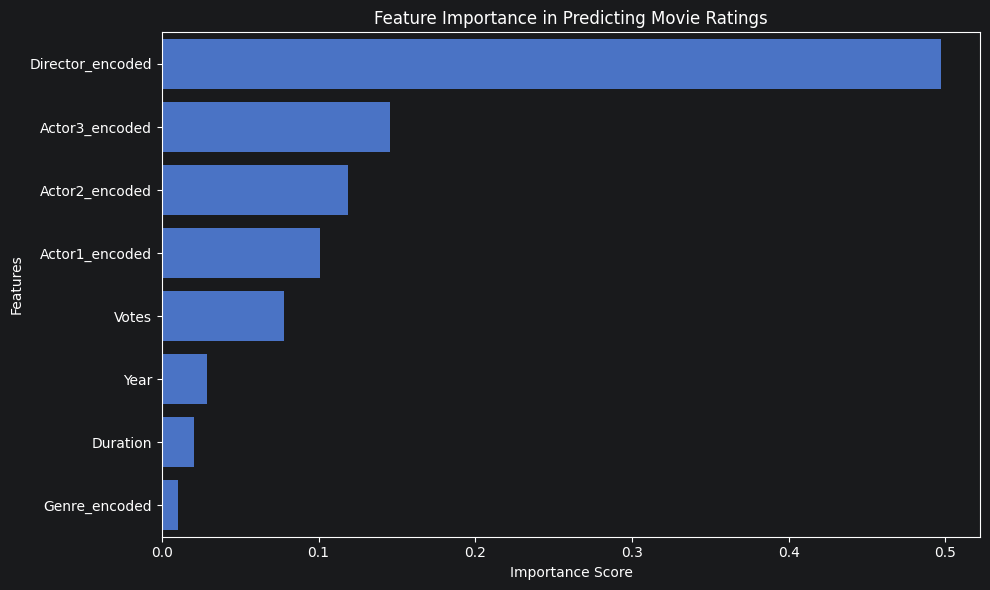

In [14]:
print("\n--- Linear Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, lr_preds):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, lr_preds):.4f}")
print(f"R-squared Score (R2): {r2_score(y_test, lr_preds):.4f}")

print("\n--- Random Forest Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, rf_preds):.4f}")
print(f"R-squared Score (R2): {r2_score(y_test, rf_preds):.4f}")

# Optional: Plotting Feature Importances for the Random Forest
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importance in Predicting Movie Ratings')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()